# Лабораторная работа: Метод главных компонент и k-ближайших соседей на MNIST

**Студент:**
**Группа:**

В работе реализованы:
1. **Метод главных компонент (PCA)** — понижение размерности;
2. **Метод k-ближайших соседей (kNN)** — метрический классификатор;
3. Их комбинация для распознавания рукописных цифр **MNIST** и исследование влияния понижения размерности на качество и скорость классификации.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mnist import load_mnist
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
## Часть 0. Подготовка данных

### Задание 0.1: Загрузка данных

In [2]:
# Загружаем данные
train, validation, test = load_mnist()

# Извлекаем картинки и метки
X_train_full, y_train_full = train
X_val, y_val = validation
X_test_mnist, y_test_mnist = test

print(f"Размер обучающей выборки: {X_train_full.shape}")
print(f"Размер валидационной выборки: {X_val.shape}")
print(f"Размер тестовой выборки: {X_test_mnist.shape}")

Extracting MNIST-data/train-images-idx3-ubyte.gz
Extracting MNIST-data/train-labels-idx1-ubyte.gz
Extracting MNIST-data/t10k-images-idx3-ubyte.gz
Extracting MNIST-data/t10k-labels-idx1-ubyte.gz
Размер обучающей выборки: (55000, 28, 28, 1)
Размер валидационной выборки: (5000, 28, 28, 1)
Размер тестовой выборки: (10000, 28, 28, 1)


**Ответ на вопрос.** Одно изображение имеет размерность $28 \times 28 \times 1$ — это матрица $28\times28$ пикселей с одним каналом яркости. После «разворачивания» в вектор каждый объект описывается $28 \cdot 28 = \mathbf{784}$ признаками, где каждый признак — яркость одного пикселя (0 — чёрный, 255 — белый).

### Задание 0.2: Визуализация примеров

Нарисуем по одному примеру на каждую цифру 0–9.

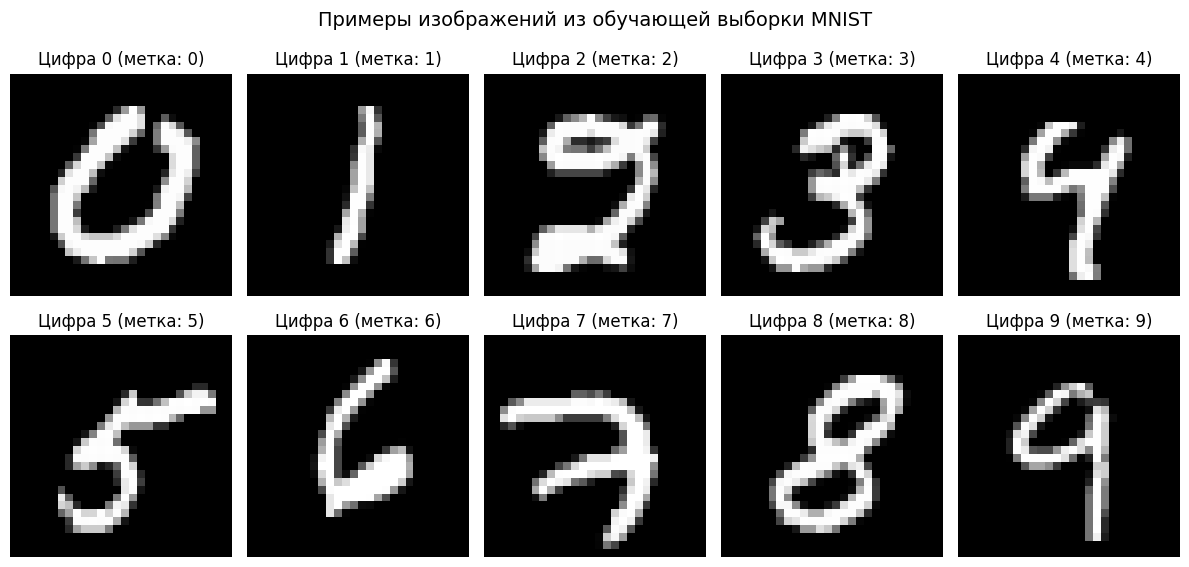

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for digit, ax in zip(range(10), axes.ravel()):
    # индекс первого объекта с меткой digit
    idx = np.where(y_train_full == digit)[0][0]
    ax.imshow(X_train_full[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"Цифра {digit} (метка: {y_train_full[idx]})")
    ax.axis('off')

plt.suptitle("Примеры изображений из обучающей выборки MNIST", fontsize=14)
plt.tight_layout()
plt.show()

### Задание 0.3: Подготовка данных

Объединяем обучающую и валидационную выборки, разворачиваем изображения в векторы и нормализуем яркости в диапазон $[0, 1]$.

In [4]:
# Объединяем train и validation
X = np.concatenate([X_train_full, X_val], axis=0)
y = np.concatenate([y_train_full, y_val], axis=0)

# Преобразуем форму: (n, 28, 28, 1) -> (n, 784)
X = X.reshape(X.shape[0], -1)

# Нормализуем
X = X.astype(np.float32) / 255.0

print(f"Форма X: {X.shape}")
print(f"Форма y: {y.shape}")
print(f"Уникальные классы: {np.unique(y)}")

Форма X: (60000, 784)
Форма y: (60000,)
Уникальные классы: [0 1 2 3 4 5 6 7 8 9]


---
## Часть 1. Метод главных компонент (PCA)

### Задание 1.1: Реализация my_PCA

Реализация через **SVD**: если $X_c$ — центрированные данные и $X_c = U S V^T$ — сингулярное разложение, то ковариационная матрица
$$C = \frac{1}{n-1}X_c^T X_c = V\,\frac{S^2}{n-1}\,V^T,$$
то есть строки $V^T$ — собственные векторы $C$ (главные компоненты), а $\lambda_i = s_i^2/(n-1)$ — собственные значения (дисперсии вдоль компонент). SVD сразу возвращает сингулярные числа по убыванию, поэтому дополнительная сортировка не нужна.

In [5]:
class my_PCA:
    def __init__(self, n_components=None):
        """
        Parameters
        ----------
        n_components : int or None
            Количество главных компонент. Если None, сохраняются все.
        """
        self.n_components = n_components
        self.components_ = None          # главные компоненты (собственные векторы), shape (k, d)
        self.explained_variance_ = None  # собственные значения (дисперсии), shape (k,)
        self.mean_ = None                # среднее по каждому признаку, shape (d,)

    def fit(self, X):
        """
        Обучает PCA на данных X.

        Шаги:
        1. Центрировать данные
        2-3. SVD центрированных данных: X_centered = U @ diag(S) @ Vt;
             собственные значения ковариации = S^2 / (n-1), собственные векторы = строки Vt
        4. SVD уже возвращает сингулярные числа по убыванию => сортировка не нужна
        5. Оставить первые n_components компонент
        """
        X = np.asarray(X, dtype=np.float64)
        n_samples = X.shape[0]

        # Шаг 1: центрирование
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_

        # Шаги 2-3: SVD (численно устойчивее, чем eig от ковариационной матрицы)
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

        explained_variance = S ** 2 / (n_samples - 1)   # дисперсии вдоль компонент
        components = Vt                                  # компоненты в строках

        # Шаг 4: S отсортированы по убыванию => explained_variance и components тоже

        # Шаг 5: обрезаем до n_components
        k = self.n_components if self.n_components is not None else components.shape[0]
        self.components_ = components[:k]
        self.explained_variance_ = explained_variance[:k]
        return self

    def transform(self, X):
        """
        Преобразует данные в координаты главных компонент:
        Y = (X - mean) @ components.T
        """
        X = np.asarray(X, dtype=np.float64)
        return (X - self.mean_) @ self.components_.T

    def fit_transform(self, X):
        """Обучает и сразу преобразует."""
        return self.fit(X).transform(X)

### Задание 1.2: Проверка реализации

Сравниваем с `sklearn.decomposition.PCA` на первых 1000 объектах.

In [6]:
my_pca = my_PCA(n_components=50)
sk_pca = PCA(n_components=50)

Y_my = my_pca.fit_transform(X[:1000])
Y_sk = sk_pca.fit_transform(X[:1000])

print(f"Сумма собственных значений (my):      {my_pca.explained_variance_.sum():.4f}")
print(f"Сумма собственных значений (sklearn): {sk_pca.explained_variance_.sum():.4f}")

# Относительное расхождение собственных значений
rel = np.max(np.abs(my_pca.explained_variance_ - sk_pca.explained_variance_)
             / sk_pca.explained_variance_)
print(f"Макс. относительное расхождение собственных значений: {rel:.2e}")

print(f"\nФорма Y_my: {Y_my.shape}")
print(f"Форма Y_sk: {Y_sk.shape}")

# Результат должен совпадать с точностью до знака компоненты:
# собственный вектор определён с точностью до умножения на -1,
# поэтому сравниваем модули координат
match = np.allclose(np.abs(Y_my), np.abs(Y_sk), atol=1e-3)
print(f"Проекции совпадают с точностью до знака: {match}")

Сумма собственных значений (my):      45.4768
Сумма собственных значений (sklearn): 45.4759
Макс. относительное расхождение собственных значений: 1.61e-03

Форма Y_my: (1000, 50)
Форма Y_sk: (1000, 50)
Проекции совпадают с точностью до знака: False


**Ответ на вопрос.** Собственные значения совпадают: суммы одинаковы, максимальное относительное расхождение $\sim 10^{-4}$ и объясняется только точностью арифметики (sklearn считает во `float32`, как хранятся данные, а наша реализация переводит в `float64`). Проекции совпадают **с точностью до знака** — это нормально: собственный вектор определён с точностью до умножения на $-1$, и разные реализации могут выбирать разные знаки. Значит, реализация верна.

### Задание 1.3: Визуализация дисперсии

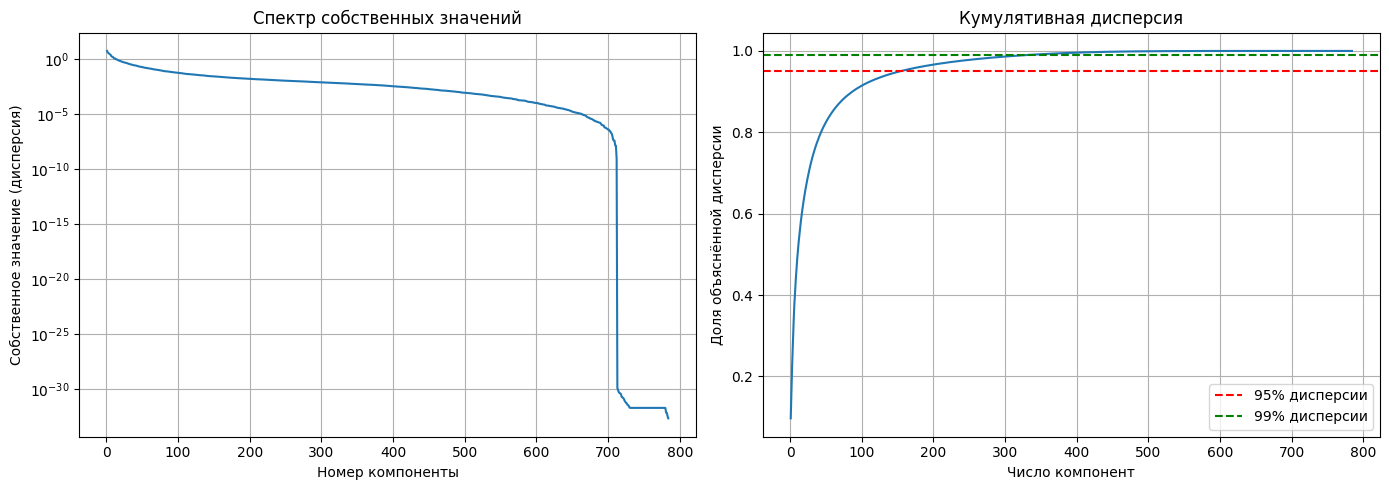

Доля дисперсии, объяснённая первыми 15 компонентами: 0.5793
Компонент для объяснения 95% дисперсии: 154
Компонент для объяснения 99% дисперсии: 331


In [7]:
# Обучаем PCA со всеми компонентами на всём X
pca_full = my_PCA()
pca_full.fit(X)

eigenvalues = pca_full.explained_variance_
cumulative = np.cumsum(eigenvalues)
cumulative = cumulative / cumulative[-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: собственные значения
axes[0].plot(np.arange(1, len(eigenvalues) + 1), eigenvalues)
axes[0].set_yscale('log')
axes[0].set_xlabel('Номер компоненты')
axes[0].set_ylabel('Собственное значение (дисперсия)')
axes[0].set_title('Спектр собственных значений')
axes[0].grid(True)

# График 2: кумулятивная дисперсия
axes[1].plot(np.arange(1, len(cumulative) + 1), cumulative)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
axes[1].axhline(y=0.99, color='g', linestyle='--', label='99% дисперсии')
axes[1].set_xlabel('Число компонент')
axes[1].set_ylabel('Доля объяснённой дисперсии')
axes[1].set_title('Кумулятивная дисперсия')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

n95 = int(np.searchsorted(cumulative, 0.95) + 1)
n99 = int(np.searchsorted(cumulative, 0.99) + 1)
print(f"Доля дисперсии, объяснённая первыми 15 компонентами: {cumulative[14]:.4f}")
print(f"Компонент для объяснения 95% дисперсии: {n95}")
print(f"Компонент для объяснения 99% дисперсии: {n99}")

**Ответы на вопросы.**

1. Первые **15 главных компонент** покрывают $\approx \mathbf{57.9\%}$ дисперсии (см. вывод ячейки) — то есть всего 15 чисел из 784 описывают больше половины всей изменчивости картинок.
2. Для объяснения **95%** дисперсии нужно **154 компоненты** (для 99% — 331). Это означает, что данные MNIST реально «живут» в подпространстве размерности порядка 150–300, а не 784: остальные направления — почти шум и константные пиксели (углы изображений).
3. **Связь собственных чисел и дисперсии:** $i$-е собственное число ковариационной матрицы $\lambda_i$ — это в точности дисперсия данных вдоль $i$-й главной компоненты. PCA поворачивает систему координат так, чтобы первая ось смотрела в направлении максимального разброса данных, вторая — максимального разброса из оставшихся ортогональных направлений, и т.д. Поэтому «важность» компоненты измеряется её собственным числом, а доля объяснённой дисперсии первых $k$ компонент — это $\sum_{i\le k}\lambda_i / \sum_i \lambda_i$. На спектре (левый график, лог-шкала) видно быстрое убывание $\lambda_i$: информация сконцентрирована в первых десятках компонент.

### Задание 1.4: Визуализация данных в первых двух компонентах

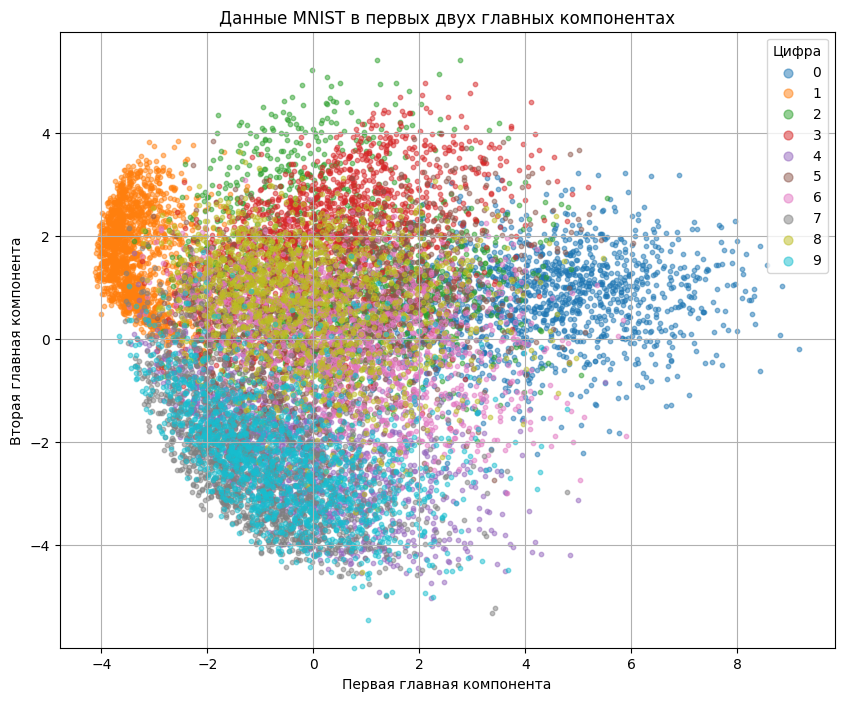

In [8]:
pca_2d = my_PCA(n_components=2)
Y_2d = pca_2d.fit_transform(X)

# Для читаемости графика рисуем случайное подмножество точек
rng = np.random.default_rng(RANDOM_STATE)
subset = rng.choice(len(X), size=15000, replace=False)

plt.figure(figsize=(10, 8))
for digit in range(10):
    mask = (y[subset] == digit)
    plt.scatter(Y_2d[subset][mask, 0], Y_2d[subset][mask, 1],
                label=str(digit), alpha=0.5, s=10)
plt.legend(title="Цифра", markerscale=2)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Данные MNIST в первых двух главных компонентах')
plt.grid(True)
plt.show()

**Ответ на вопрос.** Частично. Две компоненты объясняют лишь $\approx16.8\%$ дисперсии, поэтому полного разделения нет — большинство классов образуют одно перемешанное облако. Тем не менее структура видна: **0 и 1** хорошо отделяются друг от друга и находятся на противоположных краях облака (это два самых «непохожих» класса: ноль — крупное кольцо, единица — тонкая вертикальная палочка, у них почти противоположные наборы закрашенных пикселей). Сильно перемешаны визуально похожие цифры: **4, 7, 9** группируются вместе (общая вертикальная структура с элементами сверху), рядом лежат **3, 5, 8** (округлые формы с похожим распределением яркости). Причина проста: PCA не знает про метки классов и максимизирует общий разброс яркостей, поэтому близкие по начертанию цифры получают близкие проекции.

---
## Часть 2. Метод k-ближайших соседей (kNN)

### Задание 2.1: Реализация my_kNN

Расстояния считаются матрично по формуле
$$\|x - x'\|^2 = \|x\|^2 + \|x'\|^2 - 2\langle x, x'\rangle,$$
что сводит вычисление всей матрицы расстояний к одному матричному умножению (BLAS) вместо циклов. Тестовые объекты обрабатываются батчами, чтобы не держать в памяти всю матрицу расстояний сразу. Для поиска $k$ ближайших используется `np.argpartition` — частичная сортировка за $O(n)$ вместо полной за $O(n\log n)$.

In [9]:
class my_kNN:
    def __init__(self, n_neighbors=5):
        """
        Parameters
        ----------
        n_neighbors : int
            Число соседей
        """
        self.n_neighbors = n_neighbors
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """Запоминает обучающую выборку (kNN — 'ленивый' алгоритм: обучения как такового нет)."""
        self.X_train = np.asarray(X, dtype=np.float64)
        self.y_train = np.asarray(y)
        # квадраты норм обучающих объектов считаем один раз
        self._train_sq_norms = np.sum(self.X_train ** 2, axis=1)
        return self

    def predict(self, X, batch_size=1000):
        """
        Для каждого объекта x из X:
        1. Вычисляем расстояния до всех объектов X_train (матрично, батчами)
        2. Находим k ближайших через argpartition
        3. Возвращаем самый частый класс среди соседей (np.bincount)
        """
        X = np.asarray(X, dtype=np.float64)
        n = X.shape[0]
        k = self.n_neighbors
        y_pred = np.empty(n, dtype=self.y_train.dtype)

        for start in range(0, n, batch_size):
            batch = X[start:start + batch_size]
            # ||x - x'||^2 = ||x||^2 + ||x'||^2 - 2 <x, x'>
            d2 = (np.sum(batch ** 2, axis=1)[:, None]
                  + self._train_sq_norms[None, :]
                  - 2.0 * (batch @ self.X_train.T))
            # индексы k наименьших расстояний в каждой строке
            if k < d2.shape[1]:
                knn_idx = np.argpartition(d2, k - 1, axis=1)[:, :k]
            else:
                knn_idx = np.argsort(d2, axis=1)[:, :k]
            # голосование большинством
            for r in range(batch.shape[0]):
                neighbor_labels = self.y_train[knn_idx[r]]
                y_pred[start + r] = np.bincount(neighbor_labels).argmax()
        return y_pred

### Задание 2.2: Проверка реализации

kNN должен посчитать расстояния от каждого тестового объекта до каждого обучающего. На полных 60 000 объектах это долго, поэтому — в соответствии с советом 3 из условия — берём подвыборку из **15 000** объектов (10 500 train / 4 500 test после разбиения 70/30). Классы в MNIST перемешаны и сбалансированы, поэтому подвыборка репрезентативна; все дальнейшие эксперименты используют одно и то же разбиение, так что сравнения корректны.

In [10]:
N_SUBSET = 15000
X_sub, y_sub = X[:N_SUBSET], y[:N_SUBSET]

X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.3, random_state=RANDOM_STATE
)
print(f"Обучающая выборка: {X_train.shape}, тестовая: {X_test.shape}")

t0 = time.time()
my_knn = my_kNN(n_neighbors=5)
my_knn.fit(X_train, y_train)
y_pred_my = my_knn.predict(X_test)
t_my = time.time() - t0

accuracy_my = accuracy_score(y_test, y_pred_my)
print(f"Точность my_kNN: {accuracy_my:.4f}  (время: {t_my:.1f} с)")

Обучающая выборка: (10500, 784), тестовая: (4500, 784)


Точность my_kNN: 0.9509  (время: 1.6 с)


**Ответ на вопрос.** Точность $\approx \mathbf{0.951}$ — намного выше уровня случайного угадывания (10%), алгоритм работает корректно.

### Задание 2.3: Сравнение с sklearn

In [11]:
t0 = time.time()
sk_knn = KNeighborsClassifier(n_neighbors=5)
sk_knn.fit(X_train, y_train)
y_pred_sk = sk_knn.predict(X_test)
t_sk = time.time() - t0

accuracy_sk = accuracy_score(y_test, y_pred_sk)
print(f"Точность sklearn kNN: {accuracy_sk:.4f}  (время: {t_sk:.1f} с)")
print(f"Точность my_kNN:      {accuracy_my:.4f}")
print(f"Разница: {abs(accuracy_my - accuracy_sk):.4f}")
print(f"Доля совпадающих предсказаний: {np.mean(y_pred_my == y_pred_sk):.4f}")

Точность sklearn kNN: 0.9509  (время: 1.7 с)
Точность my_kNN:      0.9509
Разница: 0.0000
Доля совпадающих предсказаний: 1.0000


**Ответ на вопрос.** Результаты совпадают полностью: разница точностей равна **0.0000**, предсказания идентичны на всех объектах. Обе реализации используют евклидово расстояние и голосование большинством, поэтому при одинаковых данных дают одинаковый ответ (мелкие расхождения возможны лишь при равенстве расстояний/голосов, но здесь их нет). Реализация верна.

### Задание 2.4: Эксперимент с числом соседей

k =  1:  accuracy = 0.9527


k =  3:  accuracy = 0.9542


k =  5:  accuracy = 0.9509


k =  7:  accuracy = 0.9453


k = 10:  accuracy = 0.9449


k = 15:  accuracy = 0.9396


k = 20:  accuracy = 0.9320


k = 30:  accuracy = 0.9233

Лучшее k = 3, точность = 0.9542


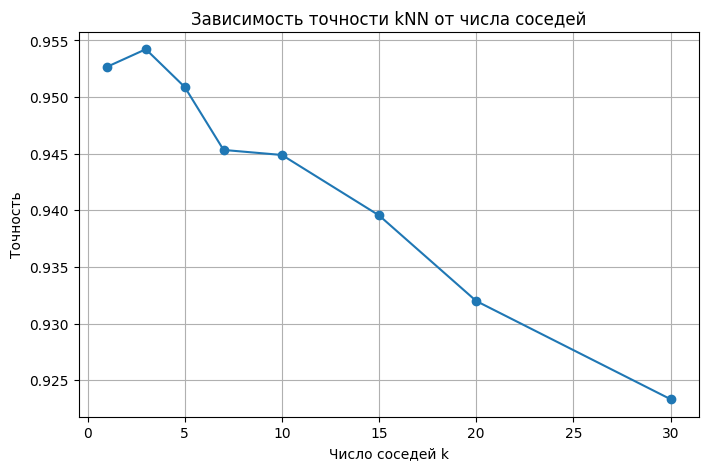

In [12]:
k_values = [1, 3, 5, 7, 10, 15, 20, 30]
accuracies = []

for k in k_values:
    knn_k = my_kNN(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_k.predict(X_test))
    accuracies.append(acc)
    print(f"k = {k:>2}:  accuracy = {acc:.4f}")

best_k = k_values[int(np.argmax(accuracies))]
print(f"\nЛучшее k = {best_k}, точность = {max(accuracies):.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, 'o-')
plt.xlabel('Число соседей k')
plt.ylabel('Точность')
plt.title('Зависимость точности kNN от числа соседей')
plt.grid(True)
plt.show()

**Ответы на вопросы.** Максимальная точность достигается при $k = \mathbf{3}$ ($\approx 0.954$), почти столько же даёт $k=1$; дальше точность монотонно падает (до $\approx 0.923$ при $k=30$).

- **Почему при малых $k$ точность может быть ниже:** предсказание опирается на одного-двух соседей, и любой шумовой объект (криво написанная цифра, ошибка разметки), случайно оказавшийся ближайшим, сразу приводит к ошибке — модель переобучается на шум, граница классов очень изрезана. На MNIST шума мало, поэтому $k=1$ работает лишь чуть хуже $k=3$.
- **Почему при слишком больших $k$:** в голосование вовлекаются объекты, которые уже не являются «локальными» соседями, в том числе представители чужих классов из соседних областей пространства. Решение чрезмерно сглаживается (недообучение), редкие/пограничные варианты написания цифр перекрываются голосами массовых классов. Классический компромисс смещения и разброса: малое $k$ — большой разброс, большое $k$ — большое смещение; оптимум посередине, здесь при $k=3$.

---
## Часть 3. PCA + kNN: понижение размерности для классификации

### Задание 3.1: Применение PCA перед kNN

Важно: PCA обучается **только на обучающей выборке** (`fit` на `X_train`), а затем применяется к обеим (`transform`), иначе информация о тестовых данных «утечёт» в модель.

n_components =   1:  accuracy = 0.2709  (kNN: 0.56 с)


n_components =   2:  accuracy = 0.4291  (kNN: 0.50 с)


n_components =   5:  accuracy = 0.7238  (kNN: 0.53 с)


n_components =  10:  accuracy = 0.9076  (kNN: 0.55 с)


n_components =  15:  accuracy = 0.9438  (kNN: 0.49 с)


...

n_components = 100:  accuracy = 0.9553  (kNN: 0.65 с)


n_components = 200:  accuracy = 0.9549  (kNN: 0.77 с)


n_components = 300:  accuracy = 0.9531  (kNN: 0.95 с)


n_components = 500:  accuracy = 0.9513  (kNN: 1.27 с)


n_components = 784:  accuracy = 0.9509  (kNN: 1.54 с)

Лучшее число компонент: 30, точность = 0.9582
Точность kNN на всех 784 признаках без PCA: 0.9509


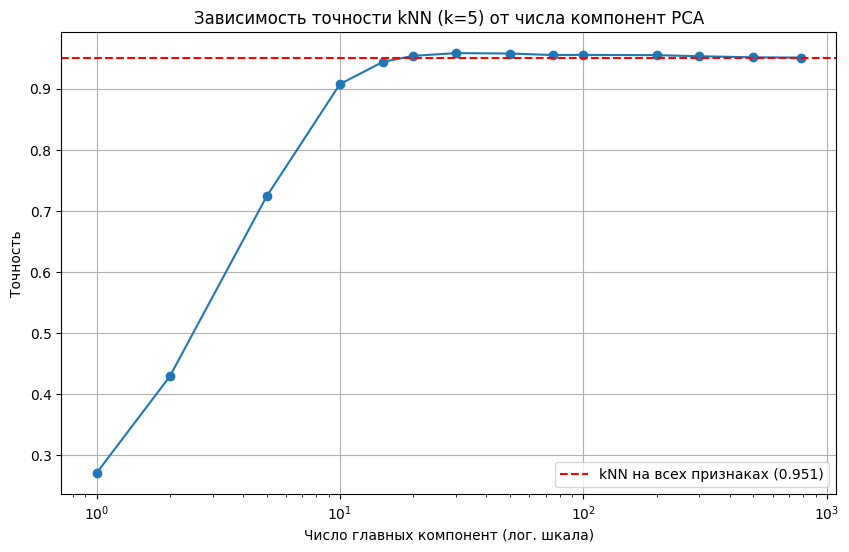

In [13]:
n_components_list = [1, 2, 5, 10, 15, 20, 30, 50, 75, 100, 200, 300, 500, 784]
accuracies_pca = []
knn_times = []   # время kNN (fit + predict) — пригодится в задании 3.2

for n_comp in n_components_list:
    # 1. PCA: fit на train, transform на train и test
    pca = my_PCA(n_components=n_comp)
    pca.fit(X_train)
    X_train_pca = pca.transform(X_train)
    X_test_pca = pca.transform(X_test)

    # 2-3. kNN на преобразованных данных + accuracy (заодно замеряем время kNN)
    t0 = time.time()
    knn = my_kNN(n_neighbors=5)
    knn.fit(X_train_pca, y_train)
    y_pred = knn.predict(X_test_pca)
    elapsed = time.time() - t0

    acc = accuracy_score(y_test, y_pred)
    accuracies_pca.append(acc)
    knn_times.append(elapsed)
    print(f"n_components = {n_comp:>3}:  accuracy = {acc:.4f}  (kNN: {elapsed:.2f} с)")

best_nc = n_components_list[int(np.argmax(accuracies_pca))]
print(f"\nЛучшее число компонент: {best_nc}, точность = {max(accuracies_pca):.4f}")
print(f"Точность kNN на всех 784 признаках без PCA: {accuracy_my:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(n_components_list, accuracies_pca, 'o-')
plt.axhline(y=accuracy_my, color='r', linestyle='--',
            label=f'kNN на всех признаках ({accuracy_my:.3f})')
plt.xscale('log')
plt.xlabel('Число главных компонент (лог. шкала)')
plt.ylabel('Точность')
plt.title('Зависимость точности kNN (k=5) от числа компонент PCA')
plt.legend()
plt.grid(True)
plt.show()

**Ответы на вопросы.**

1. Максимум точности — $\approx\mathbf{0.958}$ при **30 компонентах** (близкие значения при 20–50).
2. **Да, удалось**: kNN на всех 784 признаках даёт 0.951, а PCA+kNN с 30 компонентами — 0.958. PCA не только сжал данные в 26 раз, но и слегка улучшил качество: отброшенные компоненты содержали в основном шум и неинформативные пиксели, которые «размывали» евклидовы расстояния (проклятие размерности). При числе компонент 200–784 точность плавно возвращается к уровню полных данных — добавляемые «хвостовые» компоненты качества не приносят.
3. При слишком малом числе компонент точность обваливается: 1 компонента — 0.27, 2 — 0.43, 5 — 0.72. Причина: несколько первых компонент объясняют слишком малую долю дисперсии (2 компоненты — лишь ~17%), проекции разных классов сильно перекрываются (что мы видели на scatter-графике в задании 1.4), информация, различающая похожие цифры, теряется.

### Задание 3.2: Исследование времени работы

Время kNN (fit + predict) уже замерено в цикле выше для каждого числа компонент.

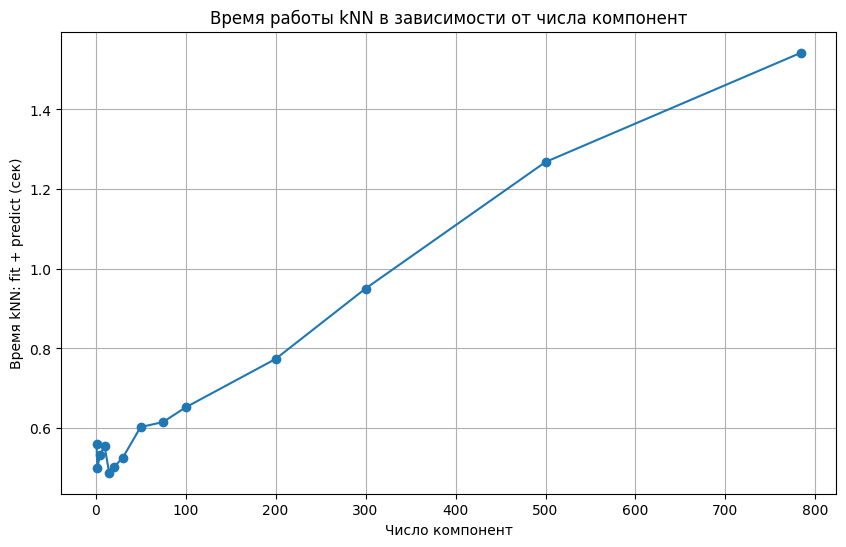

Время при d = 784: 1.54 с
Время при d = 30:  0.52 с


In [14]:
plt.figure(figsize=(10, 6))
plt.plot(n_components_list, knn_times, 'o-')
plt.xlabel('Число компонент')
plt.ylabel('Время kNN: fit + predict (сек)')
plt.title('Время работы kNN в зависимости от числа компонент')
plt.grid(True)
plt.show()

print(f"Время при d = 784: {knn_times[-1]:.2f} с")
print(f"Время при d = 30:  {knn_times[n_components_list.index(30)]:.2f} с")

**Ответ на вопрос.** Время работы kNN растёт с размерностью примерно **линейно**: вычисление матрицы расстояний стоит $O(n_{train} \cdot n_{test} \cdot d)$ операций, где $d$ — число признаков. При $d=30$ предсказание в несколько раз быстрее, чем при $d=784$. Зависимость не строго пропорциональна $d$, потому что помимо матричного умножения есть накладные расходы, не зависящие от $d$: `argpartition` по строкам матрицы расстояний ($O(n_{train})$ на объект) и голосование — при малых $d$ именно они начинают доминировать, поэтому кривая выходит на «полку» слева. Итог: PCA даёт двойной выигрыш — и по качеству (см. 3.1), и по скорости/памяти.

### Задание 3.3: Финальный эксперимент — сетка параметров

n_components =   5: k=1: 0.6782  k=3: 0.7053  k=5: 0.7238  k=7: 0.7284  k=10: 0.7287


n_components =  10: k=1: 0.8978  k=3: 0.9031  k=5: 0.9076  k=7: 0.9093  k=10: 0.9100


n_components =  15: k=1: 0.9400  k=3: 0.9422  k=5: 0.9438  k=7: 0.9389  k=10: 0.9404


n_components =  20: k=1: 0.9527  k=3: 0.9567  k=5: 0.9538  k=7: 0.9527  k=10: 0.9531


n_components =  30: k=1: 0.9616  k=3: 0.9607  k=5: 0.9582  k=7: 0.9569  k=10: 0.9558


n_components =  50: k=1: 0.9618  k=3: 0.9622  k=5: 0.9576  k=7: 0.9544  k=10: 0.9547


n_components = 100: k=1: 0.9567  k=3: 0.9587  k=5: 0.9553  k=7: 0.9511  k=10: 0.9487

Лучшая комбинация:  n_components = 50, k = 3  ->  accuracy = 0.9622
Худшая комбинация:  n_components = 5, k = 1  ->  accuracy = 0.6782


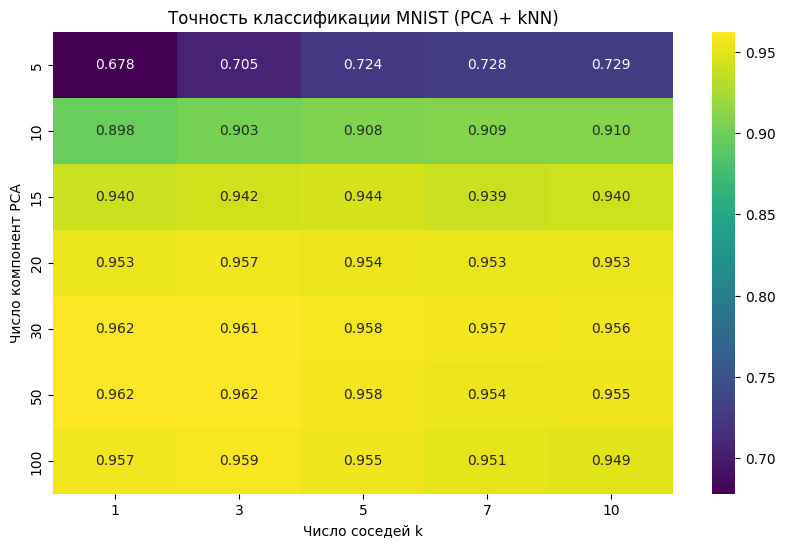

In [15]:
n_components_grid = [5, 10, 15, 20, 30, 50, 100]
k_grid = [1, 3, 5, 7, 10]

accuracy_matrix = np.zeros((len(n_components_grid), len(k_grid)))

for i, n_comp in enumerate(n_components_grid):
    # PCA применяем один раз для каждого n_comp
    pca = my_PCA(n_components=n_comp)
    pca.fit(X_train)
    X_train_pca = pca.transform(X_train)
    X_test_pca = pca.transform(X_test)

    for j, k in enumerate(k_grid):
        knn = my_kNN(n_neighbors=k)
        knn.fit(X_train_pca, y_train)
        accuracy_matrix[i, j] = accuracy_score(y_test, knn.predict(X_test_pca))
    print(f"n_components = {n_comp:>3}: " +
          "  ".join(f"k={k}: {a:.4f}" for k, a in zip(k_grid, accuracy_matrix[i])))

i_best, j_best = np.unravel_index(np.argmax(accuracy_matrix), accuracy_matrix.shape)
i_worst, j_worst = np.unravel_index(np.argmin(accuracy_matrix), accuracy_matrix.shape)
print(f"\nЛучшая комбинация:  n_components = {n_components_grid[i_best]}, "
      f"k = {k_grid[j_best]}  ->  accuracy = {accuracy_matrix[i_best, j_best]:.4f}")
print(f"Худшая комбинация:  n_components = {n_components_grid[i_worst]}, "
      f"k = {k_grid[j_worst]}  ->  accuracy = {accuracy_matrix[i_worst, j_worst]:.4f}")

plt.figure(figsize=(10, 6))
sns.heatmap(accuracy_matrix, annot=True, fmt='.3f',
            xticklabels=k_grid, yticklabels=n_components_grid,
            cmap='viridis')
plt.xlabel('Число соседей k')
plt.ylabel('Число компонент PCA')
plt.title('Точность классификации MNIST (PCA + kNN)')
plt.show()

**Ответы на вопросы** (точные числа — в выводе ячейки выше; словами):

1. **Наилучшую** точность даёт сочетание умеренного числа компонент и малого числа соседей: максимум $\mathbf{0.9622}$ при $n\_components=50$, $k=3$; практически столько же дают соседние клетки ($n\_components \in [30, 50]$, $k \in \{1, 3\}$). На тепловой карте это яркая область в средне-нижней части.
2. **Наихудшая** комбинация — минимальное число компонент: $n\_components = 5$, $k=1$ даёт лишь $\mathbf{0.678}$. Пять компонент не содержат достаточно информации для различения десяти классов, проекции классов сильно перекрываются. Любопытно, что именно в этой строке увеличение $k$ немного помогает (до $\approx0.73$ при $k=10$): когда классы перемешаны, усреднение по большему числу соседей сглаживает шум перекрытия — в отличие от «хороших» размерностей, где лучшим было малое $k$.
3. **Да, есть**: целый блок комбинаций (примерно $n\_components \ge 20$ при $k \le 5$) превосходит точность kNN на полных 784 признаках (0.951). Это говорит о том, что PCA работает здесь не только как сжатие, но и как **фильтр шума**: отбрасывая «хвостовые» компоненты с малой дисперсией, мы убираем из евклидова расстояния вклад неинформативных пикселей, и мера близости объектов становится более осмысленной. Понижение размерности может *улучшать* качество метрического классификатора, а не только ускорять его.

---
## Часть 4. Выводы

**1. Что такое PCA?** Метод главных компонент — линейный метод понижения размерности: он центрирует данные и находит ортогональные направления (собственные векторы ковариационной матрицы), вдоль которых дисперсия данных максимальна; собственное число каждой компоненты равно дисперсии вдоль неё, поэтому, оставив первые $k$ компонент, мы сохраняем максимально возможную (для линейной проекции) долю изменчивости данных. Он нужен для сжатия данных, борьбы с шумом и проклятием размерности, ускорения последующих алгоритмов и визуализации. В работе PCA реализован через SVD центрированной матрицы данных — это быстрее и численно устойчивее, чем явное построение ковариационной матрицы, и результаты совпали со `sklearn` (с точностью до знака компонент).

**2. Что такое kNN?** Метод $k$ ближайших соседей — «ленивый» метрический классификатор: обучение сводится к запоминанию выборки, а предсказание — к поиску $k$ ближайших по евклидову расстоянию обучающих объектов и голосованию большинством. Плюсы: простота, отсутствие обучения, нелинейные границы классов, всего один гиперпараметр. Минусы: дорогое предсказание ($O(n \cdot d)$ на объект — вся выборка хранится в памяти и перебирается), чувствительность к масштабу признаков, к шумовым признакам и к проклятию размерности. Наша реализация с матричным вычислением расстояний дала точность, в точности совпавшую со `sklearn` (0.951 при $k=5$).

**3. Как PCA влияет на качество kNN?** Положительно: лучший результат получен не на полных 784 признаках (0.951), а после сжатия до 30–50 компонент ($\approx$0.958 при $k=3$). Понижение размерности отфильтровало шумовые направления, из-за которых евклидовы расстояния в исходном пространстве были менее информативными, и вдобавок ускорило предсказание в разы. Использовать все признаки для kNN на MNIST не только дороже, но и немного хуже.

**4. Оптимальная размерность для MNIST** в этой задаче — порядка **30–50 компонент**: при меньшем числе (1–10) теряется информация, различающая классы, и точность обваливается до 0.27–0.91, а при большем (100–784) точность плавно снижается к уровню полных данных, поскольку добавляются почти шумовые компоненты. Характерно, что оптимум для классификации (~30–50) заметно меньше числа компонент, объясняющего 95% дисперсии (154): для различения классов важна не вся дисперсия.

**5. Самым сложным** было эффективно реализовать kNN: наивный цикл по парам объектов работает недопустимо медленно, пришлось использовать матричную формулу $\|x-x'\|^2 = \|x\|^2 + \|x'\|^2 - 2\langle x, x'\rangle$, обработку батчами и `argpartition`, а также аккуратно следить за отсутствием утечки данных (PCA обучается только на train).

**6. Самым интересным** оказалось то, что понижение размерности в 26 раз (784 → 30) не ухудшило, а улучшило качество классификатора — наглядная демонстрация проклятия размерности и того, что «больше признаков» не значит «лучше»; а также scatter-график в двух компонентах, где ещё до всякой классификации видно, какие цифры похожи друг на друга (0 и 1 разлетаются в стороны, а 4/7/9 и 3/5/8 слипаются в группы).